# 01 · Exploratory Data Analysis: Fake Job Postings
Dataset: **EMSCAD** (17,880 job posts, labelled real/fake).

In [1]:
import sys, json, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT)); warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid"); pd.set_option("display.max_colwidth", 80)

In [2]:
from src.preprocess import load_data
df = load_data()
print(df.shape)
df[["title", "location", "employment_type", "has_company_logo", "fraudulent"]].head()

(17880, 20)


,title,location,employment_type,has_company_logo,fraudulent
0,Marketing Intern,"US, NY, New York",Other,1,0
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Full-time,1,0
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",Unknown,1,0
3,Account Executive - Washington DC,"US, DC, Washington",Full-time,1,0
4,Bill Review Manager,"US, FL, Fort Worth",Full-time,1,0


## 1. Class balance
The dataset is **highly imbalanced**, so accuracy alone would be misleading.

fraudulent
Real    17014
Fake      866
Name: count, dtype: int64 
Fake share: 4.84%


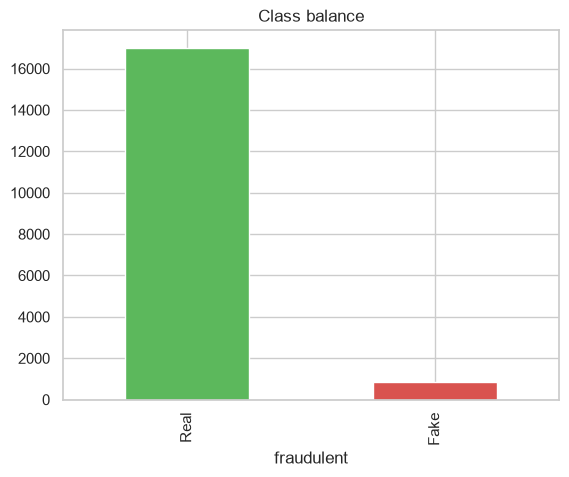

In [3]:
counts = df["fraudulent"].value_counts().rename({0: "Real", 1: "Fake"})
print(counts, f"\nFake share: {df.fraudulent.mean():.2%}")
counts.plot.bar(color=["#5cb85c", "#d9534f"], title="Class balance"); plt.show()

## 2. Missing values

In [4]:
raw = pd.read_csv(ROOT / "data/raw/fake_job_postings.csv")
(raw.isna().mean().sort_values(ascending=False) * 100).round(1).to_frame("% missing")

,% missing
salary_range,84.0
department,64.6
required_education,45.3
benefits,40.3
required_experience,39.4
function,36.1
industry,27.4
employment_type,19.4
company_profile,18.5
requirements,15.1


## 3. Fraud rate by post attributes

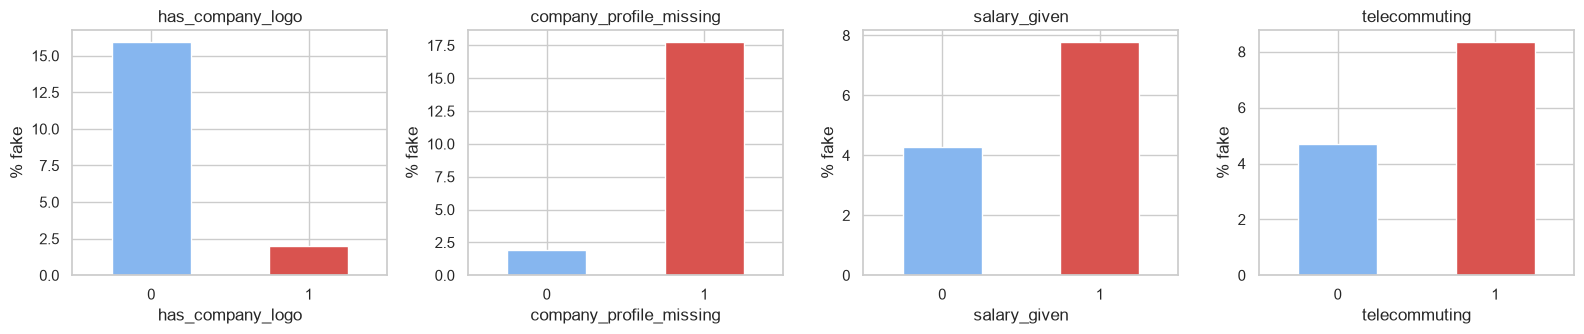

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
d = df.assign(company_profile_missing=(df.company_profile == "").astype(int),
              salary_given=(df.salary_range != "").astype(int))
for ax, col in zip(axes, ["has_company_logo", "company_profile_missing", "salary_given", "telecommuting"]):
    (d.groupby(col)["fraudulent"].mean() * 100).plot.bar(ax=ax, color=["#86b6ef", "#d9534f"], title=col)
    ax.set_ylabel("% fake"); ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

Posts **without a logo** or **without a company profile** are 8–9× more likely to be fake.

In [6]:
def rate(col, min_n=50):
    g = df.groupby(col)["fraudulent"].agg(["mean", "count"])
    return g[g["count"] >= min_n].sort_values("mean", ascending=False).head(10)
rate("industry")

,mean,count
industry,,
Oil & Energy,0.379791,287
Accounting,0.358491,159
"Leisure, Travel & Tourism",0.276316,76
Hospitality,0.159091,88
Real Estate,0.137143,175
"Health, Wellness and Fitness",0.118110,127
Hospital & Health Care,0.102616,497
Telecommunications,0.076023,342
Entertainment,0.067568,74


In [7]:
rate("function")

,mean,count
function,,
Administrative,0.188889,630
Accounting/Auditing,0.136792,212
Other,0.098462,325
Finance,0.087209,172
Engineering,0.083828,1348
Business Development,0.057018,228
Advertising,0.055556,90
Project Management,0.054645,183
Customer Service,0.054516,1229


In [8]:
for c in ["employment_type", "required_experience", "required_education"]:
    display(rate(c, 20))

,mean,count
employment_type,,
Part-time,0.092848,797
Unknown,0.069432,3471
Other,0.066079,227
Full-time,0.042169,11620
Contract,0.028871,1524
Temporary,0.008299,241


,mean,count
required_experience,,
Executive,0.070922,141
Entry level,0.066370,2697
Unknown,0.061702,7050
Not Applicable,0.053763,1116
Director,0.043702,389
Mid-Senior level,0.029667,3809
Internship,0.026247,381
Associate,0.018285,2297


,mean,count
required_education,,
Some High School Coursework,0.740741,27
Certification,0.111765,170
High School or equivalent,0.081731,2080
Master's Degree,0.074519,416
Unknown,0.055645,8105
Professional,0.054054,74
Unspecified,0.043665,1397
Doctorate,0.038462,26
Some College Coursework Completed,0.029412,102


## 4. Text length

fraudulent
0    365.0
1    233.0
Name: words, dtype: float64


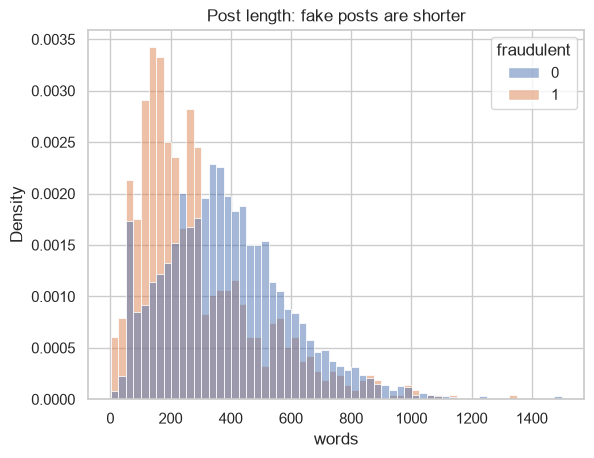

In [9]:
df["words"] = df["raw_text"].str.split().str.len()
print(df.groupby("fraudulent")["words"].median())
sns.histplot(data=df.assign(words=df["words"].clip(upper=1500)), x="words", hue="fraudulent",
             stat="density", common_norm=False, bins=60)
plt.title("Post length: fake posts are shorter"); plt.show()

## 5. Most common words in fake vs real titles

In [10]:
from collections import Counter
import re
def top(titles, k=15):
    return Counter(w for t in titles for w in re.findall(r"[a-z]{3,}", t.lower())).most_common(k)
pd.DataFrame({"fake": top(df[df.fraudulent == 1].title), "real": top(df[df.fraudulent == 0].title)})

,fake,real
0,"(data, 121)","(manager, 2176)"
1,"(entry, 108)","(developer, 1819)"
2,"(assistant, 91)","(engineer, 1548)"
3,"(engineer, 81)","(sales, 1293)"
4,"(manager, 70)","(senior, 958)"
5,"(home, 69)","(customer, 911)"
6,"(customer, 64)","(service, 850)"
7,"(clerk, 63)","(english, 788)"
8,"(payroll, 63)","(teacher, 776)"
9,"(administrative, 59)","(marketing, 769)"


## Key findings
- Only **4.8%** of posts are fake, so we need precision/recall/F1/PR-AUC and imbalance handling.
- Missing company information (logo, profile) is the strongest structural signal.
- Fake posts are shorter and concentrate in Oil & Energy, Accounting and Administrative roles.
- These findings motivated the engineered features in `src/features.py`.